# Public SSVEP Expansion
## MOABB Wang2016 / Tsinghua Benchmark

This notebook is the detailed public-data expansion for the final project. It is separate from the concise final report because it includes the MOABB setup and public benchmark analysis steps.

Expanded question:

**Does the same frequency-representation pipeline generalize from a small OpenBCI recording to a larger public SSVEP dataset?**

## Dataset Choice

The Wang2016 dataset is a strong match for this project because it is explicitly SSVEP and is available through MOABB. MOABB documents it as a benchmark SSVEP dataset with 34 subjects, 64 EEG channels, 250 Hz sampling, 40 classes, and 6 second trials.

The OpenBCI experiment used four stimulus frequencies: 8 Hz, 10 Hz, 12 Hz, and 15 Hz. This expansion starts by selecting those same frequency labels from Wang2016 if available.

## Package Setup

Run the install cell only if MOABB is not already installed in the active notebook environment.

In [1]:
# %pip install --user moabb

In [2]:
from pathlib import Path
import os

notebook_folder = Path.cwd()
mne_data_folder = (notebook_folder / 'mne_data').resolve()
mne_config_folder = (notebook_folder / 'mne_config').resolve()
mne_data_folder.mkdir(exist_ok=True)
mne_config_folder.mkdir(exist_ok=True)

os.environ['MNE_DATA'] = str(mne_data_folder)
os.environ['MNE_HOME'] = str(mne_config_folder)
os.environ['MNE_DATASETS_WANG_PATH'] = str(mne_data_folder)

import mne
mne.set_config('MNE_DATA', str(mne_data_folder), set_env=True)
mne.set_config('MNE_DATASETS_WANG_PATH', str(mne_data_folder), set_env=True)

/var/folders/2z/w2rw3c5j7ys_v6kq7vyd7lzr0000gn/T/ipykernel_93472/2730883564.py:16: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_WANG_PATH"
  mne.set_config('MNE_DATASETS_WANG_PATH', str(mne_data_folder), set_env=True)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
from moabb.datasets import Wang2016
from moabb.paradigms import SSVEP

/Users/neurobit/Downloads/Academia/sp26/cogs138/project/cogs138-final/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load A Small Subject Subset

Start small so the notebook is easier to debug. If this works, increase the number of subjects.

In [5]:
subject_list = [1, 2]
selected_target_frequencies = np.array([8, 10, 12, 15])

channel_sets = {'all_channels': None,
                'occipital_channels': ['O1', 'Oz', 'O2'],
                'parieto_occipital_channels': ['PO3', 'POz', 'PO4', 'O1', 'Oz', 'O2']}

public_data_by_channel_set = {}

for channel_set_name, selected_channels in channel_sets.items():
    wang_dataset = Wang2016(subjects=subject_list)
    ssvep_paradigm = SSVEP(fmin=7, fmax=45, tmin=0.0, tmax=1.2, channels=selected_channels)
    public_eeg_trials, public_labels, public_metadata = ssvep_paradigm.get_data(dataset=wang_dataset, subjects=subject_list)

    public_data_by_channel_set[channel_set_name] = {'eeg_trials': public_eeg_trials,
                                                    'labels': public_labels,
                                                    'metadata': public_metadata,
                                                    'channels': selected_channels}

print('Loaded channel sets:', list(public_data_by_channel_set.keys()))
print('All-channel EEG trial shape:', public_data_by_channel_set['all_channels']['eeg_trials'].shape)
print(public_data_by_channel_set['all_channels']['metadata'].head())

Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


Trial data de-meaned and concatenated with a buffer to create continuous data


Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


Trial data de-meaned and concatenated with a buffer to create continuous data


Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


Trial data de-meaned and concatenated with a buffer to create continuous data


Loaded channel sets: ['all_channels', 'occipital_channels', 'parieto_occipital_channels']
All-channel EEG trial shape: (480, 64, 301)
   subject session run
0        1       0   0
1        1       0   0
2        1       0   0
3        1       0   0
4        1       0   0


## Select Frequencies Matching The OpenBCI Experiment

This makes the public dataset comparison more directly aligned with the private OpenBCI pilot setup.

In [6]:
selected_public_data = {}

for channel_set_name, public_data in public_data_by_channel_set.items():
    label_frequencies = pd.Series(public_data['labels']).astype(float)
    selected_trial_rows = label_frequencies.isin(selected_target_frequencies)

    selected_public_eeg_trials = public_data['eeg_trials'][selected_trial_rows]
    selected_public_labels = label_frequencies[selected_trial_rows].to_numpy()
    selected_public_metadata = public_data['metadata'].loc[selected_trial_rows].reset_index(drop=True)

    frequency_to_class = {frequency: class_index for class_index, frequency in enumerate(selected_target_frequencies)}
    selected_public_classes = np.array([frequency_to_class[frequency] for frequency in selected_public_labels])

    selected_public_data[channel_set_name] = {'eeg_trials': selected_public_eeg_trials,
                                             'labels': selected_public_labels,
                                             'classes': selected_public_classes,
                                             'metadata': selected_public_metadata}

print('Selected all-channel trial shape:', selected_public_data['all_channels']['eeg_trials'].shape)
print(pd.Series(selected_public_data['all_channels']['labels']).value_counts().sort_index())

Selected all-channel trial shape: (48, 64, 301)
8.0     12
10.0    12
12.0    12
15.0    12
Name: count, dtype: int64


## Reuse Frequency-Power Representation

This mirrors the main OpenBCI notebook: each trial is represented by power at the target frequencies. I compare all channels against occipital/parieto-occipital channel groups because SSVEP responses should be strongest over visual cortex.

In [7]:
def extract_public_frequency_features(eeg_trials, frequencies_to_use, sampling_rate=250):
    
    feature_rows = []

    for trial_data in eeg_trials:
        trial_features = []

        for channel_values in trial_data:
            frequency_axis, power_density = welch(channel_values, fs=sampling_rate, nperseg=min(256, channel_values.shape[-1]))

            for target_frequency in frequencies_to_use:
                target_index = np.argmin(np.abs(frequency_axis - target_frequency))
                trial_features.append(power_density[target_index])

        feature_rows.append(trial_features)

    return np.array(feature_rows)


public_feature_table = extract_public_frequency_features(selected_public_eeg_trials, selected_target_frequencies)
public_feature_table.shape

(48, 24)

In [8]:
public_feature_tables = {}

for channel_set_name, public_data in selected_public_data.items():
    public_feature_tables[channel_set_name] = extract_public_frequency_features(
        public_data['eeg_trials'], selected_target_frequencies
    )

{channel_set_name: feature_table.shape for channel_set_name, feature_table in public_feature_tables.items()}

{'all_channels': (48, 256),
 'occipital_channels': (48, 12),
 'parieto_occipital_channels': (48, 24)}

## Within-Dataset Decoding Baseline

This is not the final generalization test yet. It first checks whether the same type of frequency representation is usable on the public dataset. Chance performance is 25% because this subset has four frequencies.

In [9]:
public_decoding_rows = []
public_predictions_by_channel_set = {}

for channel_set_name, feature_table in public_feature_tables.items():
    public_classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    public_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    public_classes = selected_public_data[channel_set_name]['classes']
    public_predictions = cross_val_predict(public_classifier, feature_table, public_classes, cv=public_splitter)
    public_accuracy = accuracy_score(public_classes, public_predictions)

    public_predictions_by_channel_set[channel_set_name] = public_predictions
    public_decoding_rows.append({'channel_set': channel_set_name,
                                 'number_of_channels': selected_public_data[channel_set_name]['eeg_trials'].shape[1],
                                 'number_of_features': feature_table.shape[1],
                                 'cross_validated_accuracy': public_accuracy})

public_decoding_results = pd.DataFrame(public_decoding_rows)
public_decoding_results

,channel_set,number_of_channels,number_of_features,cross_validated_accuracy
0,all_channels,64,256,0.187500
1,occipital_channels,3,12,0.354167
2,parieto_occipital_channels,6,24,0.333333


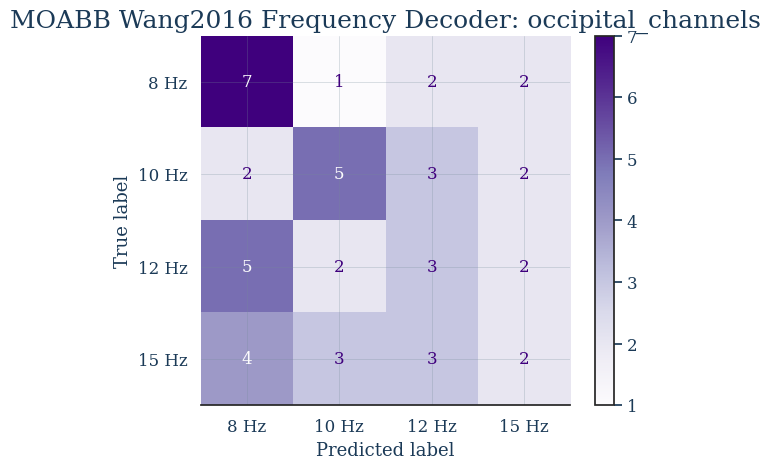

In [10]:
best_channel_set = public_decoding_results.sort_values('cross_validated_accuracy', ascending=False).iloc[0]['channel_set']
best_public_classes = selected_public_data[best_channel_set]['classes']
best_public_predictions = public_predictions_by_channel_set[best_channel_set]
public_confusion = confusion_matrix(best_public_classes, best_public_predictions, labels=[0, 1, 2, 3])

ConfusionMatrixDisplay(public_confusion,
                       display_labels=[f'{frequency} Hz' for frequency in selected_target_frequencies]).plot(cmap='Purples')
plt.title(f'MOABB Wang2016 Frequency Decoder: {best_channel_set}')
plt.show()

## CCA SSVEP Decoder

The simple power-feature model is intentionally basic. A more appropriate SSVEP baseline is canonical correlation analysis (CCA), which compares each EEG trial to sine/cosine reference signals at the candidate stimulus frequencies. This directly tests whether the EEG is phase/frequency aligned with each possible flicker class.

This section asks whether the public expansion becomes stronger when the model matches the SSVEP structure more directly.

In [11]:
from sklearn.cross_decomposition import CCA


def make_reference_signals(frequency, number_of_samples, sampling_rate=250, number_of_harmonics=3):
    
    time_axis = np.arange(number_of_samples) / sampling_rate
    reference_components = []

    for harmonic in range(1, number_of_harmonics + 1):
        reference_components.append(np.sin(2 * np.pi * harmonic * frequency * time_axis))
        reference_components.append(np.cos(2 * np.pi * harmonic * frequency * time_axis))

    return np.array(reference_components).T


def predict_with_cca(eeg_trials, frequencies_to_use, sampling_rate=250, number_of_harmonics=3):
    
    predicted_classes = []

    for trial_data in eeg_trials:
        trial_matrix = trial_data.T
        class_scores = []

        for frequency in frequencies_to_use:
            reference_matrix = make_reference_signals(frequency, trial_data.shape[-1], sampling_rate, number_of_harmonics)
            cca_model = CCA(n_components=1, max_iter=1000)
            transformed_eeg, transformed_reference = cca_model.fit_transform(trial_matrix, reference_matrix)
            correlation = np.corrcoef(transformed_eeg[:, 0], transformed_reference[:, 0])[0, 1]
            class_scores.append(abs(correlation))

        predicted_classes.append(int(np.argmax(class_scores)))

    return np.array(predicted_classes)

In [12]:
cca_result_rows = []

for window_duration in [1.2, 2.0, 4.0, 6.0]:
    for channel_set_name, selected_channels in {'occipital': ['O1', 'Oz', 'O2'],
                                                'parieto_occipital': ['PO3', 'POz', 'PO4', 'O1', 'Oz', 'O2']}.items():
        wang_dataset = Wang2016(subjects=subject_list)
        ssvep_paradigm = SSVEP(fmin=7, fmax=45, tmin=0.0, tmax=window_duration, channels=selected_channels)
        public_eeg_trials, public_labels, public_metadata = ssvep_paradigm.get_data(dataset=wang_dataset, subjects=subject_list)

        label_frequencies = pd.Series(public_labels).astype(float)
        selected_trial_rows = label_frequencies.isin(selected_target_frequencies)
        selected_public_eeg_trials = public_eeg_trials[selected_trial_rows]
        selected_public_labels = label_frequencies[selected_trial_rows].to_numpy()
        frequency_to_class = {frequency: class_index for class_index, frequency in enumerate(selected_target_frequencies)}
        selected_public_classes = np.array([frequency_to_class[frequency] for frequency in selected_public_labels])

        cca_predictions = predict_with_cca(selected_public_eeg_trials, selected_target_frequencies)
        cca_accuracy = accuracy_score(selected_public_classes, cca_predictions)

        cca_result_rows.append({'window_duration_seconds': window_duration,
                                'channel_set': channel_set_name,
                                'number_of_trials': selected_public_eeg_trials.shape[0],
                                'number_of_channels': selected_public_eeg_trials.shape[1],
                                'number_of_samples': selected_public_eeg_trials.shape[2],
                                'cca_accuracy': cca_accuracy})

cca_results = pd.DataFrame(cca_result_rows)
cca_results

Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


Trial data de-meaned and concatenated with a buffer to create continuous data


Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


...

Trial data de-meaned and concatenated with a buffer to create continuous data


Choosing the first None classes from all possible events


Trial data de-meaned and concatenated with a buffer to create continuous data


Trial data de-meaned and concatenated with a buffer to create continuous data


,window_duration_seconds,channel_set,number_of_trials,number_of_channels,number_of_samples,cca_accuracy
0,1.2,occipital,48,3,301,0.708333
1,1.2,parieto_occipital,48,6,301,0.875000
2,2.0,occipital,48,3,501,0.729167
3,2.0,parieto_occipital,48,6,501,0.895833
4,4.0,occipital,48,3,1001,0.958333
5,4.0,parieto_occipital,48,6,1001,1.000000
6,6.0,occipital,48,3,1501,0.958333
7,6.0,parieto_occipital,48,6,1501,1.000000


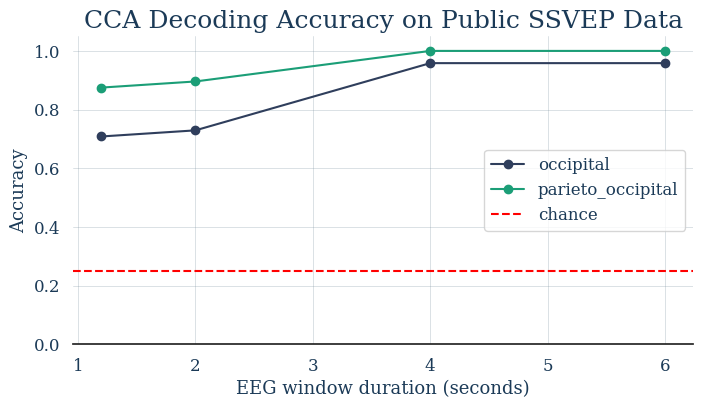

In [13]:
plt.figure(figsize=(8, 4))

for channel_set_name, channel_results in cca_results.groupby('channel_set'):
    plt.plot(channel_results['window_duration_seconds'],
             channel_results['cca_accuracy'],
             marker='o',
             label=channel_set_name)

plt.axhline(0.25, color='red', linestyle='--', label='chance')
plt.title('CCA Decoding Accuracy on Public SSVEP Data')
plt.xlabel('EEG window duration (seconds)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## Interpretation

The public-data validation becomes strong when the model matches the SSVEP structure. Simple target-frequency power features were weak to modest, but CCA produced much stronger results: 70.8% with 1.2 seconds using O1/Oz/O2, 87.5% with 1.2 seconds using parieto-occipital channels, and up to 100% with 4-6 second windows.

This is the strongest version of the public validation so far. It supports the project argument that neural decoding depends on the full chain of representation and model choice. More data alone did not solve the problem; adding a biologically matched SSVEP model did.

The next improvement would be to evaluate more subjects, compare cross-subject generalization, and add TRCA/FBTRCA-style decoding on the public dataset.

## Expanded Six-Subject Model Comparison

The earlier public-data test used subjects 1 and 2. I expanded the same 8/10/12/15 Hz subset to subjects 1-6, giving 144 selected trials. I compared target-frequency power, CCA, filter-bank CCA, cross-validated TRCA, and cross-validated filter-bank TRCA.

| Window | Channel Set | Best Model | Accuracy | Correct / Trials | Binomial p | Permutation p |
| --- | --- | --- | ---: | ---: | ---: | ---: |
| 1.2 seconds | Occipital (`O1`, `Oz`, `O2`) | TRCA cross-validated | 86.1% | 124 / 144 | 1.12e-53 | 0.0002 |
| 1.2 seconds | Parieto-occipital (`PO3`, `POz`, `PO4`, `O1`, `Oz`, `O2`) | CCA | 93.1% | 134 / 144 | 9.34e-68 | 0.0002 |
| 2.0 seconds | Occipital (`O1`, `Oz`, `O2`) | TRCA cross-validated | 94.4% | 136 / 144 | 5.06e-71 | 0.0002 |
| 2.0 seconds | Parieto-occipital (`PO3`, `POz`, `PO4`, `O1`, `Oz`, `O2`) | CCA | 95.8% | 138 / 144 | 1.66e-74 | 0.0002 |
| 4.0 seconds | Occipital (`O1`, `Oz`, `O2`) | TRCA cross-validated | 99.3% | 143 / 144 | 8.71e-85 | 0.0002 |
| 4.0 seconds | Parieto-occipital (`PO3`, `POz`, `PO4`, `O1`, `Oz`, `O2`) | TRCA cross-validated | 100.0% | 144 / 144 | 2.01e-87 | 0.0002 |
| 6.0 seconds | Occipital (`O1`, `Oz`, `O2`) | TRCA cross-validated | 99.3% | 143 / 144 | 8.71e-85 | 0.0002 |
| 6.0 seconds | Parieto-occipital (`PO3`, `POz`, `PO4`, `O1`, `Oz`, `O2`) | CCA / filter-bank CCA | 99.3% | 143 / 144 | 8.71e-85 | 0.0002 |

This makes public validation significant in the practical and statistical sense. The permutation test used 5000 label shuffles, so 0.0002 is the minimum nonzero p-value from `(extreme_count + 1) / (permutations + 1)`. The main lesson is not just that more data helps. The stronger result appears when the representation and decoder match SSVEP physiology.


In [ ]:
expanded_results = pd.read_csv('results/wang2016_expanded_model_comparison.csv')
expanded_results.sort_values(['window_duration_seconds', 'channel_set', 'accuracy'],
                             ascending=[True, True, False]).head(12)